**IMPORT LIBARIES**

In [ ]:
!pip install distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=c09e4529e84c0410e2ef45d52234b22e8cf3753b31bff4bdd1580220a71ec491
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance


In [ ]:
import os
import pickle as pkl
import multiprocessing as mp
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.utils.data import DataLoader, Sampler, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.nn import init
from torch.nn.utils import clip_grad_norm_
from torch.distributions.uniform import Uniform
from torch.optim.lr_scheduler import ReduceLROnPlateau
from datasets import load_from_disk, Dataset
from os.path import join
from typing import List, Iterator, Literal
from tqdm.auto import tqdm
import nltk
import distance
import matplotlib.pyplot as plt
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import timm

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

**GLOBAL CONFIGURATIONS**

In [3]:
NUM_WORKERS = mp.cpu_count()

In [4]:
class Config:
    data_path = "/kaggle/input/im2latex-100k/dataset"
    vocab_path = "/kaggle/input/im2latex-100k/vocab.pkl"
    save_dir = "./Checkpoint"

    # Model args
    word_emb_dim = 80
    rnn_h_dim = 512
    rnn_o_dim = 512
    enc_out_dim = 512
    att_dim = 512

    # Training args
    dropout = 0.2
    cuda = True
    batch_size = 32
    accumulation_steps = 1
    epoches = 100
    lr = 1e-4
    min_lr = 1e-5
    label_smoothing = 0.1

    # Sampling & Decay
    sample_method = "inv_sigmoid"  # choices: 'teacher_forcing', 'exp', 'inv_sigmoid'
    decay_k = 2300
    lr_decay = 0.5
    lr_patience = 2
    clip = 1.0

    # Learning rate warmup
    warmup_lr = 2e-5
    warmup_epochs = 2
    
    # Early stopping
    es_patience = 6
    es_min_delta = 1e-3

    # Misc
    seed = 2026

    # Checkpoint settings
    from_check_point = False
    checkpoint_path = "/kaggle/input/test-crnn-aug/pytorch/default/1"
    
    # Evaluation
    result_path = "./Result.txt"
    ref_path = "./Ref.txt"
    eval_batch_size = 32
    beam_size = 5
    max_len = 150

In [5]:
def seed_everything(seed):
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    
    np.random.seed(seed)

    # 2. PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        if torch.cuda.device_count() > 1:
            torch.cuda.manual_seed_all(seed)

    # 3. CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

In [6]:
args = Config()
if args.seed is not None:
    seed_everything(args.seed)

use_cuda = True if args.cuda and torch.cuda.is_available() else False
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. DATA PREPARATION

## 1.1. Configurations

In [7]:
START_TOKEN_ID = 0
PAD_TOKEN_ID = 1
END_TOKEN_ID = 2
UNK_TOKEN_ID = 3

## 1.2. Load data

### 1.2.1. Utils

In [8]:
class Vocab:
    def __init__(self):
        self.sign2id = {
            "<s>": START_TOKEN_ID,
            "</s>": END_TOKEN_ID,
            "<pad>": PAD_TOKEN_ID,
            "<unk>": UNK_TOKEN_ID,
        }
        self.id2sign = dict((idx, token) for token, idx in self.sign2id.items())
        self.length = 4

    def add_sign(self, sign):
        if sign not in self.sign2id:
            self.sign2id[sign] = self.length
            self.id2sign[self.length] = sign
            self.length += 1

    def __len__(self) -> int:
        return self.length

In [9]:
def load_vocab(filepath: str) -> Vocab:
    with open(filepath, "rb") as f:
        vocab: Vocab = pkl.load(f)
    print(f"Load vocab including {len(vocab)} Latex tokens.")
    return vocab

### 1.2.2. Load data

In [10]:
vocab = load_vocab(args.vocab_path)
vocab_size = len(vocab)

Load vocab including 394 Latex tokens.


## 1.3. Create DataLoader

### 1.3.2 Utils

In [11]:
train_transform = alb.Compose(
    [
        # Padding
        alb.PadIfNeeded(
            min_height=None, 
            min_width=None, 
            position="center",
            pad_height_divisor=16, 
            pad_width_divisor=16, 
            border_mode=0,
            fill=[255, 255, 255]
        ),

        # Geometric
        alb.Compose(
            [
                alb.Affine(
                    scale=(0.8, 1.05),      
                    rotate=(-2, 2),         
                    shear=(-2, 2),           
                    border_mode=0,
                    interpolation=4,   
                    fill=[255, 255, 255],
                    p=0.5,
                ),
                alb.Perspective(
                    scale=(0.005, 0.018),
                    border_mode=0,
                    fill=[0, 0, 0],
                    p=0.5
                ),
            ],
            p=0.5
        ),
        
        # Font thickness
        alb.OneOf([
            alb.Morphological(scale=[1, 2], operation="erosion", p=1.0),
            alb.Morphological(scale=[1, 1.5], operation="dilation", p=1.0)
        ], p=0.6),
        
        # Color variations TRƯỚC khi ToGray - để tạo diversity trong grayscale
        alb.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=10,
            p=0.5
        ),
        
        # Lighting variations
        alb.RandomBrightnessContrast(
            brightness_limit=0.1, 
            contrast_limit=(-0.3, 0.1), 
            p=0.7
        ),  
        
        # Quality degradation
        alb.ImageCompression(quality_range=(85, 95), p=0.5), 
        alb.Downscale(scale_range=[0.7, 0.95], interpolation_pair={"upscale":4,"downscale":3}, p=0.3),
        
        # Noise and blur
        alb.GaussNoise(std_range=(0.02, 0.17), p=0.2),
        alb.GaussianBlur(sigma_limit=(0.1, 0.5), p=0.3),  
        
        # Convert to grayscale
        alb.ToGray(p=1.0),
        alb.Normalize(mean=(0.9491, 0.9491, 0.9491), std=(0.1846, 0.1846, 0.1846)),
        ToTensorV2(),
    ], seed=args.seed
)

test_transform = alb.Compose(
    [
        alb.PadIfNeeded(
            min_height=None, 
            min_width=None, 
            position="center",
            pad_height_divisor=16, 
            pad_width_divisor=16, 
            border_mode=0,
            fill=[255, 255, 255]
        ),
        alb.ToGray(p=1.0),
        alb.Normalize((0.9491, 0.9491, 0.9491), (0.1846, 0.1846, 0.1846)),
        ToTensorV2(),
    ]
)

def train_transforms(batch):
    images = []
    for img in batch["image"]:
        img_array = np.array(img)
        augmented = train_transform(image=img_array)
        images.append(augmented['image'])
    batch["image"] = images
    return batch

def test_transforms(batch):
    images = []
    for img in batch["image"]:
        img_array = np.array(img)
        augmented = test_transform(image=img_array)
        images.append(augmented['image'])
    batch["image"] = images
    return batch

In [12]:
class SmartBucketSampler(Sampler):
    def __init__(
        self,
        data_source: Dataset,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = None,
    ):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.seed = seed
        self.epoch = 0
        
        self.buckets = {}
        
        print("Initializing Sampler... (Loading sizes)")
        
        # Truy cập dữ liệu một lần
        widths = data_source["width"]
        heights = data_source["height"]
        
        # Build buckets
        for idx, (w, h) in enumerate(zip(widths, heights)):
            key = (w, h)
            if key not in self.buckets:
                self.buckets[key] = []
            self.buckets[key].append(idx)
        
        # Convert to numpy arrays để tối ưu bộ nhớ và tăng tốc shuffle
        for key in self.buckets:
            self.buckets[key] = np.array(self.buckets[key], dtype=np.int32)
        
        print(f"Sampler initialized. Found {len(self.buckets)} unique buckets.")
        
        # Pre-compute bucket sizes
        self.bucket_sizes = {
            key: len(indices) for key, indices in self.buckets.items()
        }
        
        # Tính total_batches hiệu quả
        self.total_batches = sum(
            (size + (0 if self.drop_last else self.batch_size - 1)) // self.batch_size
            for size in self.bucket_sizes.values()
        )

    def __iter__(self) -> Iterator[List[int]]:
        # Tạo random generators
        if self.seed is not None:
            generator_seed = self.seed + self.epoch
            rng = random.Random(generator_seed)
            np_rng = np.random.RandomState(generator_seed)
        else:
            rng = random.Random()
            np_rng = np.random.RandomState()
        
        bucket_keys = list(self.buckets.keys())
        if self.shuffle:
            rng.shuffle(bucket_keys)
        
        batches = []
        
        for key in bucket_keys:
            # Copy numpy array
            indices = self.buckets[key].copy()
            
            if self.shuffle:
                np_rng.shuffle(indices)
            
            # Tạo batches
            num_samples = len(indices)
            for i in range(0, num_samples, self.batch_size):
                end_idx = min(i + self.batch_size, num_samples)
                batch = indices[i:end_idx].tolist()
                
                if len(batch) == self.batch_size or not self.drop_last:
                    batches.append(batch)
        
        if self.shuffle:
            rng.shuffle(batches)
        
        yield from batches

    def __len__(self) -> int:
        return self.total_batches

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

In [13]:
def collate_fn(batch):
    imgs = [item['image'] for item in batch]
    formulas = []
    
    for item in batch:
        tokens = item['formula'].split()
        formula_indices = [
            vocab.sign2id.get(token, vocab.sign2id["<unk>"]) 
            for token in tokens
        ]
        formula_indices = (
            [vocab.sign2id["<s>"]] + formula_indices + [vocab.sign2id["</s>"]]
        )
        formulas.append(torch.tensor(formula_indices, dtype=torch.long))
    
    imgs = torch.stack(imgs)
    formulas = pad_sequence(
        formulas, batch_first=True, padding_value=vocab.sign2id["<pad>"]
    )
    
    return imgs, formulas

### 1.3.2. Setup sampler

In [14]:
processed_dataset = load_from_disk(args.data_path)

In [15]:
train_dataset = processed_dataset['train']
val_dataset = processed_dataset['validation']
test_dataset = processed_dataset['test']

train_dataset.set_transform(train_transforms)
val_dataset.set_transform(test_transforms)
test_dataset.set_transform(test_transforms)

In [16]:
train_sampler = SmartBucketSampler(
    processed_dataset['train'],
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    seed=args.seed,
)

val_sampler = SmartBucketSampler(
    processed_dataset['validation'],
    batch_size=args.batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

test_sampler = SmartBucketSampler(
    processed_dataset['test'],
    batch_size=args.eval_batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 22 unique buckets.


### 1.3.3. DataLoader

In [17]:
def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [18]:
worker_init = seed_worker if (args.seed is not None) else None

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=collate_fn, 
    num_workers=NUM_WORKERS,
    pin_memory=True if use_cuda else False,
    worker_init_fn=worker_init,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory = True if use_cuda else False,
    worker_init_fn=worker_init,
)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_sampler,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory = True if use_cuda else False,
    worker_init_fn=worker_init,
)

# 2. IM2LATEX MODEL

## 2.1. Configurations

In [19]:
INIT_VALUE = 1e-2

## 2.2. Positional Encoding

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0):
        """
        Args:
            d_model: latent vector size (embedding size)
            max_len: max sequence length
            dropout: dropout rate
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a PE matrix with size (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # Position: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Calculate div_term (denominator) in log space for better precision
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Apply sin for even-indexed positions (2i)
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cos for odd-indexed positions (2i+1)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dim (1, max_len, d_model) for broadcasting when adding to embedding
        pe = pe.unsqueeze(0)

        # Register buffer so that it's not treated as learnable parameter,
        # However it will still be included in the model's state_dict
        self.register_buffer("pe", pe)

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: Input tensor with dim (Batch_size, Seq_len, d_model)
        """
        # Adding PE to embedding input (cut according to the actual length of x)
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

## 2.3 Encoder

In [21]:
class Encoder(nn.Module):
    def __init__(
        self, 
        enc_out_dim: int, 
        dropout: float
    ) -> None:
        super().__init__()

        self.cnn_encoder = timm.create_model(
                    'resnet18', 
                    pretrained=True, 
                    features_only=True, 
                    out_indices=(4,),
                    output_stride=8
                )

        self.projection = nn.Conv2d(512, enc_out_dim, kernel_size=1) if enc_out_dim != 512 else nn.Identity()
        self.pos_encoder = PositionalEncoding(enc_out_dim, 10000, dropout=0)

    def forward(self, imgs: Tensor) -> Tensor:
        
        features = self.cnn_encoder(imgs)[0]  # [B, 512, H', W']
        features = self.projection(features)
        
        encoded_imgs = features.permute(0, 2, 3, 1)
        B, H, W, C = encoded_imgs.shape
        encoded_imgs = encoded_imgs.contiguous().view(B, H * W, C)

        encoded_imgs = self.pos_encoder(encoded_imgs)

        return encoded_imgs  # [B, L, 512], L = H*W

## 2.4 Decoder

In [22]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        word_emb_dim: int,
        rnn_h_dim: int,
        rnn_o_dim: int,
        enc_out_dim: int,
        att_dim: int,
        dropout: float
    ) -> None:
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, word_emb_dim)
        self.rnn_decoder = nn.LSTMCell(rnn_o_dim + word_emb_dim, rnn_h_dim)
        self.dropout = nn.Dropout(dropout)

        # Init layers
        self.init_wh = nn.Linear(enc_out_dim, rnn_h_dim)
        self.init_wc = nn.Linear(enc_out_dim, rnn_h_dim)
        self.init_wo = nn.Linear(enc_out_dim, rnn_o_dim)

        # Attention layers
        self.beta = nn.Parameter(
            torch.Tensor(att_dim)
        )

        # Has a reasonable initial value (not too large, not too small). Helps the network learn attention scores stably from the start.
        init.uniform_(self.beta, -INIT_VALUE, INIT_VALUE)

        self.W_1 = nn.Linear(enc_out_dim, att_dim, bias=False)
        self.W_2 = nn.Linear(rnn_h_dim, att_dim, bias=False)
        self.W_3 = nn.Linear(rnn_h_dim + enc_out_dim, rnn_o_dim, bias=False)
        self.W_out = nn.Linear(rnn_o_dim, vocab_size, bias=False)

    def init_decoder_states(self, enc_out: Tensor) -> tuple[tuple[Tensor, Tensor], Tensor]:
        """
        Args:
          enc_out: the output of encoder [B, H*W, C]
        Returns:
          h_0, c_0:  h_0 and c_0's shape: [B, rnn_h_dim]
          init_o : the average of enc_out  [B, rnn_o_dim]
          for decoder
        """
        mean_enc_out = enc_out.mean(dim=1)  # [B, H*W, C] -> [B, C]
        h = torch.tanh(self.init_wh(mean_enc_out))   
        c = torch.tanh(self.init_wc(mean_enc_out))
        init_o = torch.tanh(self.init_wo(mean_enc_out))
        return (h, c), init_o

    def forward_step(
        self,
        dec_states: tuple[Tensor, Tensor],
        o_t: Tensor,
        enc_out: Tensor,
        projected_enc: Tensor,
        tgt: Tensor,
    ) -> tuple[tuple[Tensor, Tensor], Tensor, Tensor]:
        """Runing one step decoding"""

        # RNN stage
        prev_y = self.embedding(tgt).squeeze(1)  # prev_y's shape: [B, emb_size]
        inp = torch.cat([prev_y, o_t], dim=1)  # inp's shape: [B, emb_size + rnn_o_dim]
        h_t, c_t = self.rnn_decoder(inp, dec_states)  # h_t and c_t's shape: [B, rnn_h_dim]
        h_t = self.dropout(h_t)
        c_t = self.dropout(c_t)

        # Attention stage
        alpha = torch.tanh(
            projected_enc + self.W_2(h_t).unsqueeze(1)
        )  # [B, L, att_dim] + [B, 1, att_dim] -> [B, L, att_dim]
        alpha = torch.sum(self.beta * alpha, dim=-1)  # [B, L]
        alpha = F.softmax(alpha, dim=-1)  # [B, L]

        # calc context: [B, C]
        context_t = torch.bmm(
            alpha.unsqueeze(1), enc_out
        )  # batch mat mult [B, 1, L] @ [B, L, C] -> [B, 1, C]
        context_t = context_t.squeeze(1) # [B, 1, C] -> [B, C]

        # Output stage
        o_t = self.W_3(torch.cat([h_t, context_t], dim=1)).tanh()
        o_t = self.dropout(o_t)
        logit = self.W_out(o_t)  # [B, vocab_size]

        return (h_t, c_t), o_t, logit

## 2.3. Model

In [23]:
class Im2LatexModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        word_emb_dim: int,
        rnn_h_dim: int,
        rnn_o_dim: int,
        enc_out_dim: int,
        att_dim: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.encoder = Encoder(enc_out_dim, dropout)
        self.decoder = Decoder(vocab_size, word_emb_dim, rnn_h_dim, rnn_o_dim, enc_out_dim, att_dim, dropout)
        self.uniform = Uniform(0, 1) # Schedule sampling

    
    def forward(self, imgs: Tensor, formulas: Tensor, epsilon: float) -> Tensor:
        """
        Args:
            imgs: [B, 1, H, W]
            formulas: [B, MAX_LEN], each token is a number
            epsilon: probability of the current time step to
                    use the true previous token
        Returns:
            logits: [B, MAX_LEN, VOCAB_SIZE]
        """
        # 1. Encoding
        enc_out = self.encoder(imgs)  # [B, 1, H, W] -> [B, H'*W', 512]

        # 2. Initialize decoder states
        dec_states, o_t = self.decoder.init_decoder_states(enc_out)

        # 3. Precompute for better performance, its shape: [B, L, att_dim]
        projected_encoder_output = self.decoder.W_1(enc_out)

        # 4. Loop to decode
        max_len = formulas.size(1)
        logits = []
        prev_logit = None
        for t in range(max_len):
            tgt = formulas[:, t : t + 1]  # True label, shape: [B, 1]

            # Schedule sampling
            if prev_logit is not None and self.uniform.sample().item() > epsilon:
                tgt = torch.argmax(prev_logit.detach(), dim=1, keepdim=True) 

            # One step decoding
            dec_states, o_t, logit = self.decoder.forward_step(
                    dec_states, o_t, enc_out, projected_encoder_output, tgt
            )  # At each step returns 1 batch, logit: [B, vocab_size]
            
            prev_logit = logit.detach()
            logits.append(logit)

        logits = torch.stack(logits, dim=1)  # [B, MAX_LEN, vocab_size]
        return logits

# 3. TRAINING

## 3.1. Helper function

**Functions for trainer**

In [24]:
def cal_loss(logits: Tensor, targets: Tensor, label_smoothing: float = 0.1) -> Tensor:
    "logits: [B, L, V], targets: [B, L]"

    # [B*L, V] each row [V] in logits_flat corresponds to a token in the batch
    logits_flat = logits.contiguous().view(-1, logits.size(-1))

    # [B*L] Each value in targets_flat is the correct token index
    targets_flat = targets.contiguous().view(-1)

    # Calculate cross entropy loss
    return F.cross_entropy(logits_flat, targets_flat, ignore_index=PAD_TOKEN_ID, label_smoothing=label_smoothing)


def cal_epsilon(
    k: float, step: int, method: Literal["inv_sigmoid", "exp", "teacher_forcing"]
) -> float:
    """
    Reference:
        Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks
        See details in https://arxiv.org/pdf/1506.03099.pdf
    """
    assert method in ["inv_sigmoid", "exp", "teacher_forcing"]

    if method == "exp":
        return k**step
    elif method == "inv_sigmoid":
        return k / (k + math.exp(step / k))
    else:
        return 1.0

**Function to get our checkpoint**

In [25]:
def get_checkpoint(save_dir, mode="latest") -> str:
    """
    Auto find checkpoint (New format only).
    - mode='latest': returns path to 'last_model.pt'
    - mode='best': returns path to 'best_model.pt'
    """
    if not os.path.exists(save_dir):
        raise FileNotFoundError(f"Directory does not exist: {save_dir}")

    # Xác định tên file dựa trên mode
    if mode == "latest":
        target_name = "last_model.pt"
    elif mode == "best":
        target_name = "best_model.pt"
    else:
        raise ValueError(f"Unknown mode: {mode}. Use 'latest' or 'best'.")

    target_path = join(save_dir, target_name)

    # Kiểm tra file có tồn tại không
    if not os.path.exists(target_path):
        raise FileNotFoundError(f"Checkpoint '{target_name}' not found in {save_dir}")

    print(f"Found {mode} checkpoint: {target_path}")
    return target_path

**Learning rate scheduler wrapper**

In [26]:
class LinearWarmupScheduler:
    def __init__(
        self, 
        optimizer, 
        warmup_epochs, 
        warmup_lr, 
        target_lr, 
        plateau_scheduler
    ):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.warmup_lr = warmup_lr
        self.target_lr = target_lr
        self.plateau_scheduler = plateau_scheduler
        self.last_epoch = 0

        # Khởi tạo LR ở mức bắt đầu (warmup_lr)
        self._set_lr(self.warmup_lr)

    def _set_lr(self, lr):
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def step(self, metrics):
        self.last_epoch += 1

        # Giai đoạn 1: Warmup (Tăng tuyến tính)
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / self.warmup_epochs
            current_lr = self.warmup_lr + alpha * (self.target_lr - self.warmup_lr)
            self._set_lr(current_lr)
        
        # Giai đoạn 2: kết thúc Warmup
        elif self.last_epoch == self.warmup_epochs:
            print(f"\n[Scheduler] Warmup finished! LR reached target: {self.target_lr}")
            self._set_lr(self.target_lr)
            
            # Reset Plateau để không tính các biến động loss trong lúc warmup
            self.plateau_scheduler._reset()

        # Giai đoạn 3: Sau Warmup -> Chuyển giao hoàn toàn cho ReduceLROnPlateau
        else:
            self.plateau_scheduler.step(metrics)

    def state_dict(self):
        return {
            'last_epoch': self.last_epoch,
            'plateau_state': self.plateau_scheduler.state_dict()
        }

    def load_state_dict(self, state_dict):
        self.last_epoch = state_dict['last_epoch']
        self.plateau_scheduler.load_state_dict(state_dict['plateau_state'])

## 3.2. Trainer

In [27]:
class Trainer(object):
    def __init__(
        self,
        optimizer,
        model,
        train_loader,
        val_loader,
        args,
        lr_scheduler,
        use_cuda=True,
        init_epoch=1,
        last_epoch=200,
    ):

        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model.to(self.device)
        if torch.cuda.device_count() > 1:
            print(f"Detect {torch.cuda.device_count()} GPUs! Running in parallel.")
            self.model = nn.DataParallel(self.model)
        
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.epoch = init_epoch
        self.total_step = (init_epoch - 1) * len(train_loader)
        self.last_epoch = last_epoch
        self.best_val_loss = 1e18

        self.args = args
        self.lr_scheduler = lr_scheduler
        self.wait = 0

    def train(self):
        history = {'train_loss': [], 'val_loss': []}

        while self.epoch <= self.last_epoch:
            self.model.train()
            self.train_loader.batch_sampler.set_epoch(self.epoch)

            pbar = tqdm(
                self.train_loader,
                desc=f"Epoch {self.epoch}/{self.last_epoch}",
                unit="batch",
                leave=False,
            )
            epoch_losses = 0.0

            self.optimizer.zero_grad(set_to_none=True)

            for i, (imgs, formulas) in enumerate(pbar):
                imgs: Tensor = imgs.to(self.device)
                formulas: Tensor = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]

                step_loss = self.train_step(imgs, tgt4training, tgt4cal_loss, i)

                epoch_losses += step_loss
                current_avg_loss = epoch_losses / (i + 1)
                current_lr = self.optimizer.param_groups[0]["lr"]

                pbar.set_postfix(
                    {
                        "Loss": f"{step_loss:.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                        "LR": f"{current_lr:.6f}",
                    }
                )
            avg_train_loss = epoch_losses / len(self.train_loader)
            history['train_loss'].append(avg_train_loss)

            # Validate
            val_loss = self.validate()
            history['val_loss'].append(val_loss)

            self.lr_scheduler.step(val_loss)

            self.save_model("last_model") 

            tqdm.write(f"[EPOCH {self.epoch}] Train: loss = {current_avg_loss:.4f}, ppl = {math.exp(current_avg_loss):.4f}, lr = {current_lr:.6f}")
            tqdm.write(f"        [VALIDATION] loss = {val_loss:.4f}, ppl = {math.exp(val_loss):.4f}")
            if val_loss < (self.best_val_loss - self.args.es_min_delta):
                tqdm.write(f"        Validation loss improved from {self.best_val_loss:.4f} -> {val_loss:.4f}. Saving best model...")
                self.best_val_loss = val_loss
                self.save_model("best_model")
                self.wait = 0
            else:
                self.wait += 1
                tqdm.write(f"EarlyStopping counter: {self.wait} out of {self.args.es_patience}")
                if self.wait >= self.args.es_patience:
                    tqdm.write("Early stopping triggered! Stop training.")
                    break

            self.epoch += 1
        
        # [NEW] Trả về history để vẽ biểu đồ
        return history

    def train_step(
        self, imgs: Tensor, tgt4training: Tensor, tgt4cal_loss: Tensor, step_idx: int
    ) -> float:
        # Code gốc đã bỏ Autocast/Scaler theo yêu cầu trước đó
        epsilon = cal_epsilon(
            self.args.decay_k, self.total_step, self.args.sample_method
        )

        logits = self.model(imgs, tgt4training, epsilon)
        loss = cal_loss(logits.float(), tgt4cal_loss, self.args.label_smoothing)
        loss = loss / self.args.accumulation_steps

        loss.backward() 

        if (step_idx + 1) % self.args.accumulation_steps == 0:
            clip_grad_norm_(self.model.parameters(), self.args.clip)
            self.optimizer.step()
            self.optimizer.zero_grad(set_to_none=True)
            self.total_step += 1

        return loss.item() * self.args.accumulation_steps

    def validate(self) -> float:
        self.model.eval()
        val_total_loss = 0.0

        pbar = tqdm(self.val_loader, desc=f"Validating Epoch {self.epoch}", unit="batch", leave=False)

        with torch.no_grad():
            for i, (imgs, formulas) in enumerate(pbar):
                imgs = imgs.to(self.device)
                formulas = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]
                
                epsilon = 1

                logits = self.model(imgs, tgt4training, epsilon)
                loss = cal_loss(logits, tgt4cal_loss, label_smoothing=0.0)

                val_total_loss += loss.item()
                current_avg_loss = val_total_loss / (i + 1)
                pbar.set_postfix(
                    {
                        "Val Loss": f"{loss.item():.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                    }
                )

            avg_loss = val_total_loss / len(self.val_loader)

        return avg_loss


    def save_model(self, model_name: str):
        if not os.path.isdir(self.args.save_dir):
            os.makedirs(self.args.save_dir)
        
        # model_name bây giờ sẽ là "best_model" hoặc "last_model"
        save_path = join(self.args.save_dir, model_name + ".pt")

        if isinstance(self.model, nn.DataParallel):
            model_state_dict = self.model.module.state_dict()
        else:
            model_state_dict = self.model.state_dict()

        torch.save(
            {
                "epoch": self.epoch,
                "model_state_dict": model_state_dict,
                "optimizer_state_dict": self.optimizer.state_dict(),
                "lr_sche": self.lr_scheduler.state_dict(),
                "args": self.args,
                "best_val_loss": self.best_val_loss,
                "wait": self.wait,
            },
            save_path,
        )

## 3.3. Perform training

**Load model**

In [28]:
model = Im2LatexModel(
    vocab_size,
    args.word_emb_dim,
    args.rnn_h_dim,
    args.rnn_o_dim,
    args.enc_out_dim,
    args.att_dim,
    args.dropout,
)
print(model)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Im2LatexModel(
  (encoder): Encoder(
    (cnn_encoder): FeatureListNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act1): ReLU(inplace=True)
          (aa): Identity()
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act2): ReLU(inplace=True)
        )
        (1): BasicBlock(
      

**Setup optimizer and others**

In [29]:
# Construct optimizer
optimizer = optim.Adam(model.parameters(), lr=args.lr)

base_scheduler = ReduceLROnPlateau(
    optimizer,
    "min",
    factor=args.lr_decay,
    patience=args.lr_patience,
    min_lr=args.min_lr,
)

lr_scheduler = LinearWarmupScheduler(
    optimizer=optimizer,
    warmup_epochs=args.warmup_epochs, 
    warmup_lr=args.warmup_lr,         
    target_lr=args.lr,                
    plateau_scheduler=base_scheduler
)

print("Model and Optimizer initialized.")

Model and Optimizer initialized.


**Let's train**

In [30]:
# --- 1. Init temp var ---
start_epoch = 1
loaded_best_loss = float('inf')
loaded_wait = 0

if args.from_check_point:
    print("Loading checkpoint...")
    checkpoint_path = get_checkpoint(args.checkpoint_path)
    checkpoint = torch.load(checkpoint_path, weights_only=False)

    args = checkpoint["args"]
    args.from_check_point = False

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    
    lr_scheduler.load_state_dict(checkpoint["lr_sche"])

    # Load state var
    start_epoch = checkpoint["epoch"] + 1
    loaded_best_loss = checkpoint["best_val_loss"]
    loaded_wait = checkpoint["wait"]
    print(f"Resuming from epoch {start_epoch}, Best Loss: {loaded_best_loss:.4f}")

# --- 2. Init Trainer ---
# Now create the trainer object
trainer = Trainer(
    optimizer,
    model,
    train_loader,
    val_loader,
    args,
    lr_scheduler,
    use_cuda=use_cuda,
    init_epoch=start_epoch,
    last_epoch=args.epoches,
)

# --- 3. Inject state to Trainer ---
if args.from_check_point:
    trainer.best_val_loss = loaded_best_loss
    trainer.wait = loaded_wait

# --- 4. Train ---
print("Start Training...")
history = trainer.train()

Detect 2 GPUs! Running in parallel.
Start Training...


Epoch 1/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

Validating Epoch 1:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 1] Train: loss = 3.6639, ppl = 39.0134, lr = 0.000020
        [VALIDATION] loss = 2.7837, ppl = 16.1785
        Validation loss improved from 1000000000000000000.0000 -> 2.7837. Saving best model...


Epoch 2/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

...

Validating Epoch 12:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 12] Train: loss = 2.9977, ppl = 20.0390, lr = 0.000050
        [VALIDATION] loss = 1.5893, ppl = 4.9003
EarlyStopping counter: 5 out of 6


Epoch 13/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

Validating Epoch 13:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 13] Train: loss = 2.9825, ppl = 19.7365, lr = 0.000050
        [VALIDATION] loss = 1.7248, ppl = 5.6114
EarlyStopping counter: 6 out of 6
Early stopping triggered! Stop training.


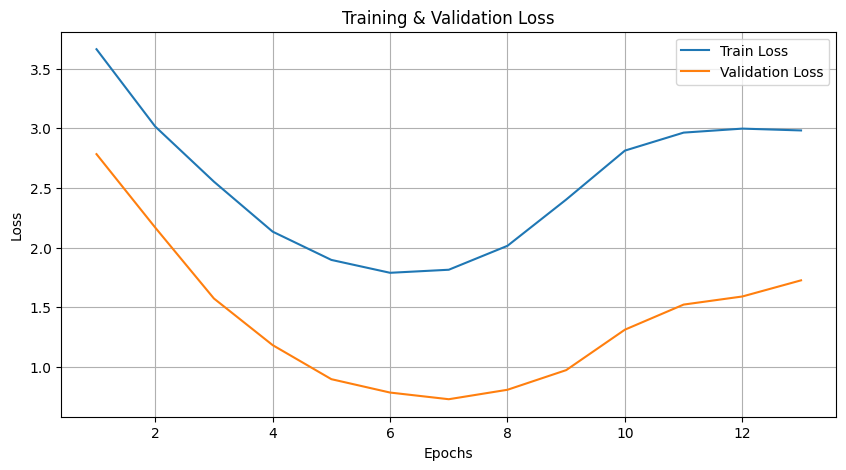

In [31]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(10, 5))

# Truyền 'epochs' vào làm trục x
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')

plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.savefig('./training_validation_loss_plot.png') 
plt.show()

# 5. EVALUATION

## 5.1 Utils

### 5.1.1 Utils for decoding

In [ ]:
# code borrow from: https://github.com/luopeixiang/im2latex/blob/master/model/beam_search.py
class BeamSearch:
    """
    Implements the beam search algorithm for decoding the most likely sequences.

    Parameters
    ----------
    end_index : ``int``
        The index of the "stop" or "end" token in the target vocabulary.
    max_steps : ``int``, optional (default = 50)
        The maximum number of decoding steps to take, i.e. the maximum length
        of the predicted sequences.
    beam_size : ``int``, optional (default = 10)
        The width of the beam used.
    per_node_beam_size : ``int``, optional (default = beam_size)
        The maximum number of candidates to consider per node, at each step in the search.
        If not given, this just defaults to ``beam_size``. Setting this parameter
        to a number smaller than ``beam_size`` may give better results, 
        as it can introduce more diversity into the search. 
        See `Beam Search Strategies for Neural Machine Translation.
        Freitag and Al-Onaizan, 2017 <http://arxiv.org/abs/1702.01806>`_.
    """

    def __init__(self,
                 end_index: int,
                 max_steps: int = 50,
                 beam_size: int = 10,
                 per_node_beam_size: int = None) -> None:
        self._end_index = end_index
        self.max_steps = max_steps
        self.beam_size = beam_size
        self.per_node_beam_size = per_node_beam_size or beam_size

    def search(self, start_predictions, start_state, step):
        """
        Given a starting state and a step function, apply beam search to find the
        most likely target sequences.

        Notes
        -----
        If your step function returns ``-inf`` for some log probabilities
        (like if you're using a masked log-softmax) then some of the "best"
        sequences returned may also have ``-inf`` log probability. Specifically
        this happens when the beam size is smaller than the number of actions
        with finite log probability (non-zero probability) returned by the step function.
        Therefore if you're using a mask you may want to check the results from ``search``
        and potentially discard sequences with non-finite log probability.

        Parameters
        ----------
        start_predictions : ``torch.Tensor``
            A tensor containing the initial predictions with shape ``(batch_size,)``.
            Usually the initial predictions are just the index of the "start" token
            in the target vocabulary.
        start_state : ``dict``
            The initial state passed to the ``step`` function. 
            Each value of the state dict should be a tensor of shape ``(batch_size, *)``, 
            where ``*`` means any other number of dimensions.
        step : ``function``
            A function that is responsible for computing the next most likely tokens,
            given the current state and the predictions from the last time step.
            The function should accept two arguments. The first being a tensor
            of shape ``(group_size,)``, representing the index of the predicted
            tokens from the last time step, and the second being the current state.
            The ``group_size`` will be ``batch_size * beam_size``, except in the initial
            step, for which it will just be ``batch_size``.
            The function is expected to return a tuple, where the first element
            is a tensor of shape ``(group_size, target_vocab_size)`` containing
            the log probabilities of the tokens for the next step, and the second
            element is the updated state. The tensor in the state should have shape
            ``(group_size, *)``, where ``*`` means any other number of dimensions.

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Tuple of ``(predictions, log_probabilities)``, where ``predictions``
            has shape ``(batch_size, beam_size, max_steps)`` and ``log_probabilities``
            has shape ``(batch_size, beam_size)``.
        """
        batch_size = start_predictions.size()[0]

        # List of (batch_size, beam_size) tensors. One for each time step. Does not
        # include the start symbols, which are implicit.
        predictions = []

        # List of (batch_size, beam_size) tensors. One for each time step. None for
        # the first.  Stores the index n for the parent prediction, i.e.
        # predictions[t-1][i][n], that it came from.
        backpointers = []

        # Calculate the first timestep. This is done outside the main loop
        # because we are going from a single decoder input (the output from the
        # encoder) to the top `beam_size` decoder outputs. On the other hand,
        # within the main loop we are going from the `beam_size` elements of the
        # beam to `beam_size`^2 candidates from which we will select the top
        # `beam_size` elements for the next iteration.
        # shape: (batch_size, num_classes)
        start_class_log_probabilities, state = step(
            start_predictions, start_state)

        num_classes = start_class_log_probabilities.size()[1]

        # shape: (batch_size, beam_size), (batch_size, beam_size)
        start_top_log_probabilities, start_predicted_classes = \
            start_class_log_probabilities.topk(self.beam_size)
        if self.beam_size == 1 and (start_predicted_classes == self._end_index).all():
            print("Empty sequences predicted. You may want to "
                  "increase the beam size or ensure "
                  "your step function is working properly.")
            return start_predicted_classes.unsqueeze(-1), start_top_log_probabilities

        # The log probabilities for the last time step.
        # shape: (batch_size, beam_size)
        last_log_probabilities = start_top_log_probabilities

        # shape: [(batch_size, beam_size)]
        predictions.append(start_predicted_classes)

        # Log probability tensor that mandates that the end token is selected.
        # shape: (batch_size * beam_size, num_classes)
        log_probs_after_end = start_class_log_probabilities.new_full(
            (batch_size * self.beam_size, num_classes),
            float("-inf")
        )
        log_probs_after_end[:, self._end_index] = 0.

        # Set the same state for each element in the beam.
        for key, state_tensor in state.items():
            _, *last_dims = state_tensor.size()
            # shape: (batch_size * beam_size, *)
            state[key] = state_tensor.\
                unsqueeze(1).\
                expand(batch_size, self.beam_size, *last_dims).\
                reshape(batch_size * self.beam_size, *last_dims)

        for timestep in range(self.max_steps - 1):
            # shape: (batch_size * beam_size,)
            last_predictions = predictions[-1].reshape(
                batch_size * self.beam_size)

            # If every predicted token from the last step is `self._end_index`,
            # then we can stop early.
            if (last_predictions == self._end_index).all():
                break

            # Take a step. This get the predicted log probs of the next classes
            # and updates the state.
            # shape: (batch_size * beam_size, num_classes)
            class_log_probabilities, state = step(last_predictions, state)

            # shape: (batch_size * beam_size, num_classes)
            last_predictions_expanded = last_predictions.unsqueeze(-1).expand(
                batch_size * self.beam_size,
                num_classes
            )

            # Here we are finding any beams where we predicted the end token in
            # the previous timestep and replacing the distribution with a
            # one-hot distribution, forcing the beam to predict the end token
            # this timestep as well.
            # shape: (batch_size * beam_size, num_classes)
            cleaned_log_probabilities = torch.where(
                last_predictions_expanded == self._end_index,
                log_probs_after_end,
                class_log_probabilities
            )

            # shape (both): (batch_size * beam_size, per_node_beam_size)
            top_log_probabilities, predicted_classes = \
                cleaned_log_probabilities.topk(self.per_node_beam_size)

            # Here we expand the last log probabilities to (batch_size * beam_size, per_node_beam_size)
            # so that we can add them to the current log probs for this timestep.
            # This lets us maintain the log probability of each element on the beam.
            # shape: (batch_size * beam_size, per_node_beam_size)
            expanded_last_log_probabilities = last_log_probabilities.\
                unsqueeze(2).\
                expand(batch_size, self.beam_size, self.per_node_beam_size).\
                reshape(batch_size * self.beam_size, self.per_node_beam_size)

            # shape: (batch_size * beam_size, per_node_beam_size)
            summed_top_log_probabilities = top_log_probabilities + \
                expanded_last_log_probabilities

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_summed = summed_top_log_probabilities.\
                reshape(batch_size, self.beam_size * self.per_node_beam_size)

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_predicted_classes = predicted_classes.\
                reshape(batch_size, self.beam_size * self.per_node_beam_size)

            # Keep only the top `beam_size` beam indices.
            # shape: (batch_size, beam_size), (batch_size, beam_size)
            restricted_beam_log_probs, restricted_beam_indices = reshaped_summed.topk(
                self.beam_size)

            # Use the beam indices to extract the corresponding classes.
            # shape: (batch_size, beam_size)
            restricted_predicted_classes = reshaped_predicted_classes.gather(
                1, restricted_beam_indices)

            predictions.append(restricted_predicted_classes)

            # shape: (batch_size, beam_size)
            last_log_probabilities = restricted_beam_log_probs

            # The beam indices come from a `beam_size * per_node_beam_size` dimension where the
            # indices with a common ancestor are grouped together. Hence
            # dividing by per_node_beam_size gives the ancestor. (Note that this is integer
            # division as the tensor is a LongTensor.)
            # shape: (batch_size, beam_size)
            backpointer = restricted_beam_indices // self.per_node_beam_size

            backpointers.append(backpointer)

            # Keep only the pieces of the state tensors corresponding to the
            # ancestors created this iteration.
            for key, state_tensor in state.items():
                _, *last_dims = state_tensor.size()
                # shape: (batch_size, beam_size, *)
                expanded_backpointer = backpointer.\
                    view(batch_size, self.beam_size, *([1] * len(last_dims))).\
                    expand(batch_size, self.beam_size, *last_dims)

                # shape: (batch_size * beam_size, *)
                state[key] = state_tensor.\
                    reshape(batch_size, self.beam_size, *last_dims).\
                    gather(1, expanded_backpointer).\
                    reshape(batch_size * self.beam_size, *last_dims)

        if not torch.isfinite(last_log_probabilities).all():
            print("Infinite log probabilities encountered. "
                  "Some final sequences may not make sense. "
                  "This can happen when the beam size is "
                  "larger than the number of valid (non-zero "
                  "probability) transitions that the step function produces.")

        # Reconstruct the sequences.
        # shape: [(batch_size, beam_size, 1)]
        reconstructed_predictions = [predictions[-1].unsqueeze(2)]

        # shape: (batch_size, beam_size)
        cur_backpointers = backpointers[-1]

        for timestep in range(len(predictions) - 2, 0, -1):
            # shape: (batch_size, beam_size, 1)
            cur_preds = predictions[timestep].gather(
                1, cur_backpointers).unsqueeze(2)

            reconstructed_predictions.append(cur_preds)

            # shape: (batch_size, beam_size)
            cur_backpointers = backpointers[timestep -
                                            1].gather(1, cur_backpointers)

        # shape: (batch_size, beam_size, 1)
        final_preds = predictions[0].gather(1, cur_backpointers).unsqueeze(2)

        reconstructed_predictions.append(final_preds)

        # shape: (batch_size, beam_size, max_steps)
        all_predictions = torch.cat(
            list(reversed(reconstructed_predictions)), 2)

        return all_predictions, last_log_probabilities

In [33]:
class LatexProducer(object):
    """
    Model wrapper, implementing batch greedy decoding and
    batch beam search decoding
    """

    def __init__(self, model, vocab, beam_size=5, max_len=64, use_cuda=True):
        """args:
            the path to model checkpoint
        """
        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model.to(self.device)
        self._sign2id = vocab.sign2id
        self._id2sign = vocab.id2sign
        self.max_len = max_len
        self.beam_size = beam_size
        self._beam_search = BeamSearch(END_TOKEN_ID, max_len, beam_size)

    def __call__(self, imgs):
        """args:
            imgs: images need to be decoded
            beam_size: if equal to 1, use greedy decoding
           returns:
            formulas list of batch_size length
        """
        if self.beam_size == 1:
            results = self._greedy_decoding(imgs)
        else:
            results = self._batch_beam_search(imgs)
        return results

    def _idx2formulas(self, formulas_idx):
        """convert formula id matrix to formulas list"""
        results = []
        for formula in formulas_idx:
            formula = formula.tolist()
            result = []
            for idx in formula:
                if idx == END_TOKEN_ID:
                    break
                if idx != START_TOKEN_ID and idx != PAD_TOKEN_ID:
                    result.append(self._id2sign[idx])
            results.append(" ".join(result))
        return results

    def _greedy_decoding(self, imgs):
        self.model.eval()
        imgs = imgs.to(self.device)
        
        enc_out = self.model.encoder(imgs)
        dec_states, o_t = self.model.decoder.init_decoder_states(enc_out)
        projected_enc = self.model.decoder.W_1(enc_out)

        batch_size = imgs.size(0)
        # storing decoding results
        formulas_idx = torch.ones(
            batch_size, self.max_len, device=self.device).long() * PAD_TOKEN_ID
        # first decoding step's input
        tgt = torch.ones(
            batch_size, 1, device=self.device).long() * START_TOKEN_ID
        with torch.no_grad():
            for t in range(self.max_len):
                dec_states, o_t, logit = self.model.decoder.forward_step(
                    dec_states, o_t, enc_out, projected_enc, tgt
                )

                tgt = torch.argmax(logit, dim=1, keepdim=True)
                formulas_idx[:, t:t + 1] = tgt
        results = self._idx2formulas(formulas_idx)
        return results

    def _batch_beam_search(self, imgs):
            self.model.eval()
            imgs = imgs.to(self.device)
            
            # Encoding
            enc_out = self.model.encoder(imgs)  # [batch_size, H*W, OUT_C]
            
            # Init Decoder
            dec_states, o_t = self.model.decoder.init_decoder_states(enc_out)
            
            # Precompute projection
            projected_enc = self.model.decoder.W_1(enc_out)
            
            batch_size = imgs.size(0)
            start_predictions = torch.ones(
                batch_size, 1, device=self.device).long() * START_TOKEN_ID
            
            # Đóng gói state vào dict
            state = {}
            state['h_t'] = dec_states[0] # LSTM hidden
            state['c_t'] = dec_states[1] # LSTM cell
            state['o_t'] = o_t
            state['enc_out'] = enc_out
            state['projected_enc'] = projected_enc
            
            # Gọi Beam Search
            # Trả về: [B, K, Max_Len], [B, K]
            with torch.no_grad():
                all_top_k_predictions, log_probabilities = self._beam_search.search(
                    start_predictions, state, self._take_step)
    
            # Lấy kết quả tốt nhất (Beam index 0 vì đã sort trong beam search)
            best_predictions = all_top_k_predictions[:, 0, :]
            
            # Chuyển thành text
            results = self._idx2formulas(best_predictions)
            return results

    def _take_step(self, last_predictions, state):
            """
            Hàm này chạy forward step cho [Batch * Beam_Size] mẫu cùng lúc
            """
            # Unpack state
            # Lưu ý: Các tensor này đã được BeamSearch expand thành [B*K, ...]
            h_t = state['h_t']
            c_t = state['c_t']
            o_t = state['o_t']
            enc_out = state['enc_out']            
            projected_enc = state['projected_enc']
            
            dec_states = (h_t, c_t)
            
            # Model Forward Step
            # last_predictions shape: [B*K, 1]
            dec_states, o_t, logit = self.model.decoder.forward_step(
                dec_states, o_t, enc_out, projected_enc, last_predictions
            )
    
            # Cập nhật lại state mới vào dict để trả về cho BeamSearch quản lý
            new_state = {}
            new_state['h_t'] = dec_states[0]
            new_state['c_t'] = dec_states[1]
            new_state['o_t'] = o_t
            new_state['enc_out'] = enc_out 
            new_state['projected_enc'] = projected_enc 
            
            # Trả về log_softmax để cộng dồn điểm số
            return torch.log_softmax(logit, dim=1), new_state

### 5.2.2 Utils for calc score

In [34]:
def score_files(path_ref, path_hyp):
    """Loads result from file and score it

    Args:
        path_ref: (string) formulas of reference
        path_hyp: (string) formulas of prediction.

    Returns:
        scores: (dict)

    """
    # load formulas
    formulas_ref = load_formulas(path_ref)
    formulas_hyp = load_formulas(path_hyp)

    assert len(formulas_ref) == len(formulas_hyp)

    # tokenize
    refs = [ref.split(' ') for _, ref in formulas_ref.items()]
    hyps = [hyp.split(' ') for _, hyp in formulas_hyp.items()]

    # score
    return {
        "BLEU-4": bleu_score(refs, hyps)*100,
        "EM": exact_match_score(refs, hyps)*100,
        "Edit": edit_distance(refs, hyps)*100
    }


def exact_match_score(references, hypotheses):
    """Computes exact match scores.

    Args:
        references: list of list of tokens (one ref)
        hypotheses: list of list of tokens (one hypothesis)

    Returns:
        exact_match: (float) 1 is perfect

    """
    exact_match = 0
    for ref, hypo in zip(references, hypotheses):
        if np.array_equal(ref, hypo):
            exact_match += 1

    return exact_match / float(max(len(hypotheses), 1))


def bleu_score(references, hypotheses):
    """Computes bleu score.

    Args:
        references: list of list (one hypothesis)
        hypotheses: list of list (one hypothesis)

    Returns:
        BLEU-4 score: (float)

    """
    references = [[ref] for ref in references]  # for corpus_bleu func
    BLEU_4 = nltk.translate.bleu_score.corpus_bleu(
        references, hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25)
    )
    return BLEU_4


def edit_distance(references, hypotheses):
    """Computes Levenshtein distance between two sequences.

    Args:
        references: list of list of token (one hypothesis)
        hypotheses: list of list of token (one hypothesis)

    Returns:
        1 - levenshtein distance: (higher is better, 1 is perfect)

    """
    d_leven, len_tot = 0, 0
    for ref, hypo in zip(references, hypotheses):
        d_leven += distance.levenshtein(ref, hypo)
        len_tot += float(max(len(ref), len(hypo)))

    return 1. - d_leven / len_tot

def load_formulas(filename):
    formulas = dict()
    with open(filename) as f:
        for idx, line in enumerate(f):
            formulas[idx] = line.strip()
    print("Loaded {} formulas from {}".format(len(formulas), filename))
    return formulas

## 5.2 Perform evaluation


**Load best model**

In [35]:
checkpoint_path = get_checkpoint(args.save_dir, 'best')
checkpoint = torch.load(checkpoint_path, weights_only=False)

model_args = checkpoint['args']

Found best checkpoint: ./Checkpoint/best_model.pt


In [36]:
eval_model = Im2LatexModel(
    vocab_size,
    model_args.word_emb_dim,
    model_args.rnn_h_dim,
    model_args.rnn_o_dim,
    model_args.enc_out_dim,
    model_args.att_dim,
    model_args.dropout,
)
eval_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

**Decoding**

In [37]:
result_file = open(args.result_path, 'w')
ref_file = open(args.ref_path, 'w')

latex_producer = LatexProducer(
    eval_model, vocab, max_len=args.max_len,
    use_cuda=use_cuda, beam_size=args.beam_size)

for imgs, formulas in tqdm(test_loader):
    try:
        tgt4cal_loss = formulas[:, 1:]
        reference = latex_producer._idx2formulas(tgt4cal_loss)
        results = latex_producer(imgs)
    except RuntimeError as e:
        print(f"\nĐã xảy ra lỗi tại batch này: {e}")
        traceback.print_exc()
        break

    result_file.write('\n'.join(results))
    ref_file.write('\n'.join(reference))

result_file.close()
ref_file.close()

  0%|          | 0/323 [00:00<?, ?it/s]

**Scoring**

In [38]:
score = score_files(args.result_path, args.ref_path)
print("beam search result:", score)

Loaded 9606 formulas from ./Result.txt
Loaded 9606 formulas from ./Ref.txt
beam search result: {'BLEU-4': 61.07020048986775, 'EM': 4.268165729752238, 'Edit': 68.74750723705372}
